In [7]:
import pandas as pd

df = pd.read_csv("bangladesh_student_performance.csv")
print(df.shape)
print(df.head())

(1000, 14)
   Student_ID  Gender  Age    District School_Type  Study_Hours_per_Week  \
0           1    Male   16     Rangpur     Private                    11   
1           2  Female   17    Rajshahi     Private                     7   
2           3    Male   15     Barisal     Private                    27   
3           4    Male   15  Mymensingh     Private                    18   
4           5    Male   15  Mymensingh      Public                    28   

   Attendance  Parent_Education  Family_Income_BDT Internet_Access  \
0          70          Graduate              49169             Yes   
1          76           Primary              57947              No   
2          63  Higher Secondary              57224             Yes   
3          84           Primary              55865              No   
4          89  Higher Secondary              35553              No   

  Private_Tuition  Previous_GPA  SSC_Result  HSC_Result  
0             Yes          4.83        4.22        5.

In [8]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1000 non-null   int64  
 1   Gender                1000 non-null   str    
 2   Age                   1000 non-null   int64  
 3   District              1000 non-null   str    
 4   School_Type           1000 non-null   str    
 5   Study_Hours_per_Week  1000 non-null   int64  
 6   Attendance            1000 non-null   int64  
 7   Parent_Education      1000 non-null   str    
 8   Family_Income_BDT     1000 non-null   int64  
 9   Internet_Access       1000 non-null   str    
 10  Private_Tuition       1000 non-null   str    
 11  Previous_GPA          1000 non-null   float64
 12  SSC_Result            1000 non-null   float64
 13  HSC_Result            1000 non-null   float64
dtypes: float64(3), int64(5), str(6)
memory usage: 109.5 KB
None

Missing values:
Student

Performance distribution:
Performance
1    506
0    494
Name: count, dtype: int64

High performers: 506
Low performers: 494


C:\Users\RAKSHITHA\AppData\Local\Temp\ipykernel_22960\4166638216.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Performance', data=df, palette='coolwarm')


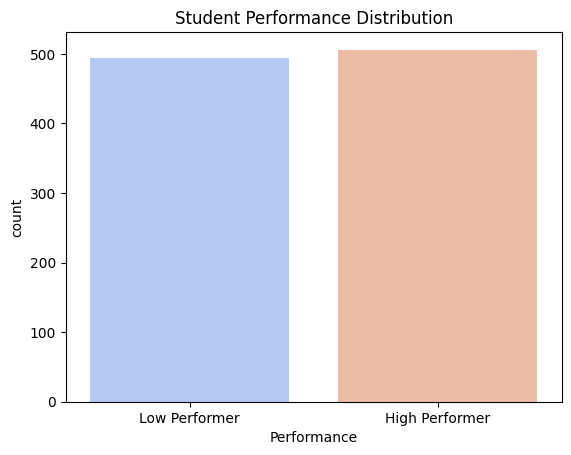

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create target variable
df['Performance'] = (df['HSC_Result'] >= 4.0).astype(int)

print("Performance distribution:")
print(df['Performance'].value_counts())
print(f"\nHigh performers: {df['Performance'].sum()}")
print(f"Low performers: {(df['Performance'] == 0).sum()}")

# Visualize
sns.countplot(x='Performance', data=df, palette='coolwarm')
plt.title('Student Performance Distribution')
plt.xticks([0, 1], ['Low Performer', 'High Performer'])
plt.show()

C:\Users\RAKSHITHA\AppData\Local\Temp\ipykernel_22960\3142025808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Performance', y='Study_Hours_per_Week', data=df, ax=axes[0], palette='coolwarm')
C:\Users\RAKSHITHA\AppData\Local\Temp\ipykernel_22960\3142025808.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Low', 'High'])
C:\Users\RAKSHITHA\AppData\Local\Temp\ipykernel_22960\3142025808.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Performance', y='Attendance', data=df, ax=axes[1], palette='coolwarm')
C:\Users\RAKSHITHA\AppData\Local\Temp\ipykernel_22960\3142025808

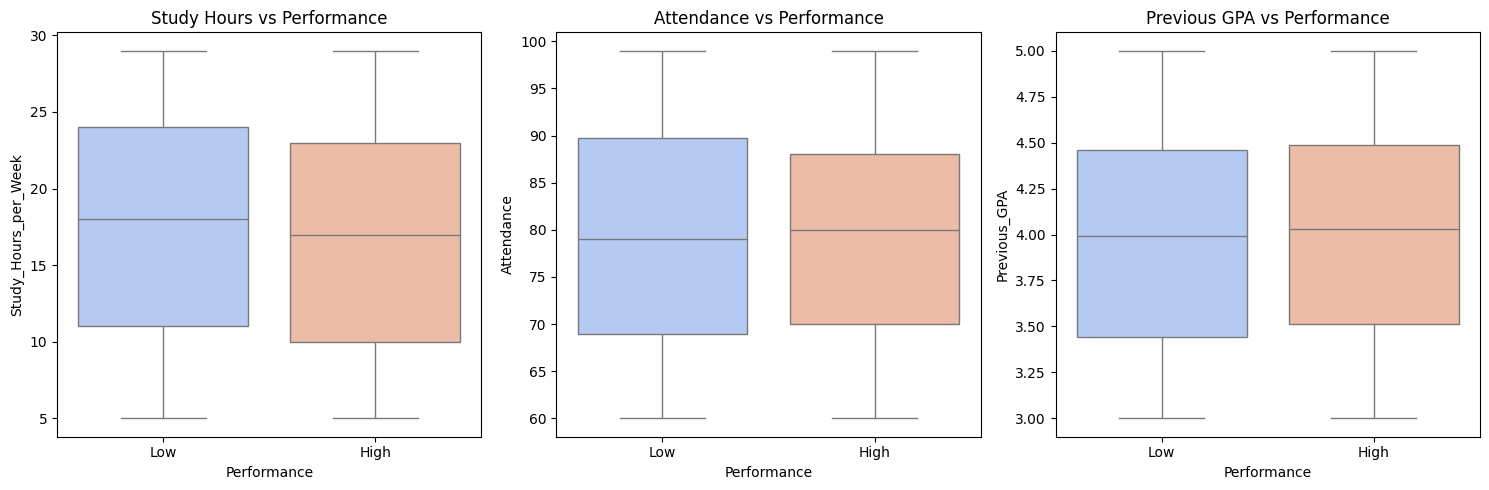

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Study hours vs Performance
sns.boxplot(x='Performance', y='Study_Hours_per_Week', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Study Hours vs Performance')
axes[0].set_xticklabels(['Low', 'High'])

# Attendance vs Performance
sns.boxplot(x='Performance', y='Attendance', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Attendance vs Performance')
axes[1].set_xticklabels(['Low', 'High'])

# Previous GPA vs Performance
sns.boxplot(x='Performance', y='Previous_GPA', data=df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Previous GPA vs Performance')
axes[2].set_xticklabels(['Low', 'High'])

plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

# Drop columns we don't need
df_model = df.drop(['Student_ID', 'HSC_Result', 'SSC_Result'], axis=1)

# Convert text columns to numbers
le = LabelEncoder()
text_columns = ['Gender', 'District', 'School_Type', 'Parent_Education', 
                'Internet_Access', 'Private_Tuition']

for col in text_columns:
    df_model[col] = le.fit_transform(df_model[col])

print("Data ready for model!")
print(df_model.head())
print(df_model.shape)

Data ready for model!
   Gender  Age  District  School_Type  Study_Hours_per_Week  Attendance  \
0       1   16         6            0                    11          70   
1       0   17         5            0                     7          76   
2       1   15         0            0                    27          63   
3       1   15         4            0                    18          84   
4       1   15         4            1                    28          89   

   Parent_Education  Family_Income_BDT  Internet_Access  Private_Tuition  \
0                 0              49169                1                1   
1                 2              57947                0                0   
2                 1              57224                1                1   
3                 2              55865                0                0   
4                 1              35553                0                1   

   Previous_GPA  Performance  
0          4.83            1  
1       

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split features and target
X = df_model.drop('Performance', axis=1)
y = df_model['Performance']

# Split into training and testing data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"\nLogistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")

Training samples: 800
Testing samples: 200


c:\Users\RAKSHITHA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Accuracy: 52.50%
Random Forest Accuracy: 55.00%


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Fix Logistic Regression with scaling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

# Random Forest doesn't need scaling
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")
print(f"\nWinner: {'Random Forest' if rf_accuracy > lr_accuracy else 'Logistic Regression'}")

# Detailed report for best model
print("\nDetailed Report (Random Forest):")
print(classification_report(y_test, rf_pred, target_names=['Low Performer', 'High Performer']))

Logistic Regression Accuracy: 50.00%
Random Forest Accuracy: 55.00%

Winner: Random Forest

Detailed Report (Random Forest):
                precision    recall  f1-score   support

 Low Performer       0.55      0.49      0.52        98
High Performer       0.55      0.61      0.58       102

      accuracy                           0.55       200
     macro avg       0.55      0.55      0.55       200
  weighted avg       0.55      0.55      0.55       200



In [14]:
# Create a stronger target based on multiple factors
df['Pass'] = ((df['HSC_Result'] >= 4.0) & (df['SSC_Result'] >= 4.0)).astype(int)

print("New target distribution:")
print(df['Pass'].value_counts())

# Rebuild model dataframe with new target
df_model2 = df.drop(['Student_ID', 'HSC_Result', 'SSC_Result'], axis=1)

text_columns = ['Gender', 'District', 'School_Type', 'Parent_Education', 
                'Internet_Access', 'Private_Tuition']

for col in text_columns:
    df_model2[col] = le.fit_transform(df_model2[col])

df_model2['Pass'] = df['Pass']
df_model2 = df_model2.drop('Performance', axis=1)

X2 = df_model2.drop('Pass', axis=1)
y2 = df_model2['Pass']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train2, y_train2)
rf2_pred = rf2.predict(X_test2)

print(f"New Random Forest Accuracy: {accuracy_score(y_test2, rf2_pred)*100:.2f}%")

New target distribution:
Pass
0    657
1    343
Name: count, dtype: int64
New Random Forest Accuracy: 66.50%


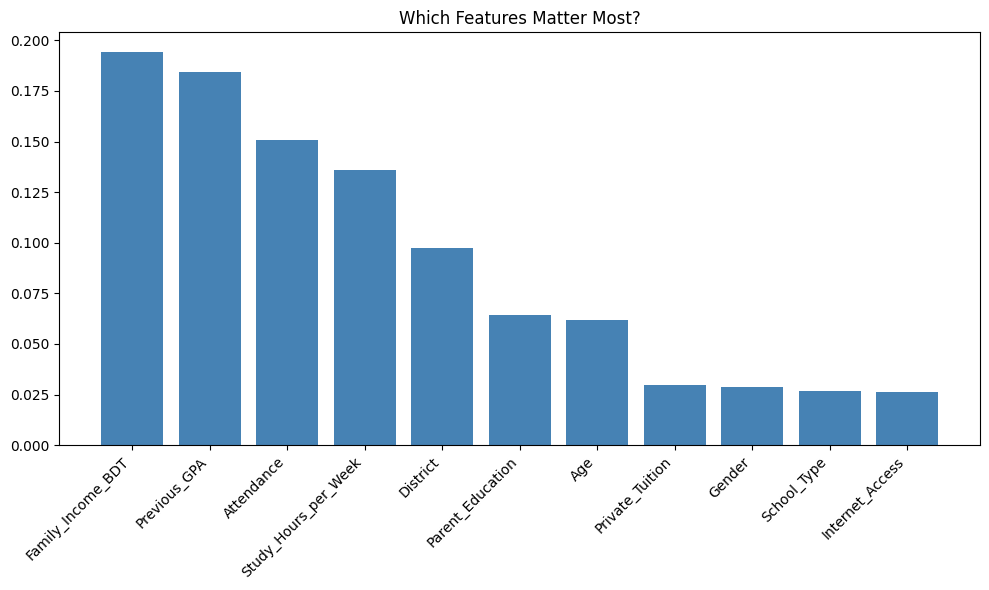

Feature Importance Ranking:
1. Family_Income_BDT: 19.42%
2. Previous_GPA: 18.44%
3. Attendance: 15.09%
4. Study_Hours_per_Week: 13.59%
5. District: 9.72%
6. Parent_Education: 6.43%
7. Age: 6.20%
8. Private_Tuition: 2.99%
9. Gender: 2.85%
10. School_Type: 2.67%
11. Internet_Access: 2.61%


In [15]:
import numpy as np

# Get feature importances from Random Forest
feature_names = X2.columns
importances = rf2.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.title('Which Features Matter Most?')
plt.bar(range(X2.shape[1]), importances[indices], color='steelblue')
plt.xticks(range(X2.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print ranking
print("Feature Importance Ranking:")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]*100:.2f}%")

In [16]:
def predict_student(study_hours, attendance, previous_gpa, family_income, 
                    gender=1, age=17, district=3, school_type=0,
                    parent_education=1, internet_access=1, private_tuition=0):
    
    input_data = pd.DataFrame([[gender, age, district, school_type, study_hours,
                                 attendance, parent_education, family_income,
                                 internet_access, private_tuition, previous_gpa]],
                               columns=X2.columns)
    
    prediction = rf2.predict(input_data)[0]
    probability = rf2.predict_proba(input_data)[0]
    
    print(f"Prediction: {'HIGH Performer ✅' if prediction == 1 else 'LOW Performer ⚠️'}")
    print(f"Confidence: {max(probability)*100:.1f}%")

# Test it
print("--- Student 1: High study hours, good attendance ---")
predict_student(study_hours=25, attendance=90, previous_gpa=4.5, family_income=50000)

print("\n--- Student 2: Low study hours, poor attendance ---")
predict_student(study_hours=5, attendance=60, previous_gpa=3.0, family_income=20000)

--- Student 1: High study hours, good attendance ---
Prediction: LOW Performer ⚠️
Confidence: 58.0%

--- Student 2: Low study hours, poor attendance ---
Prediction: LOW Performer ⚠️
Confidence: 61.0%


In [17]:
print("--- Student 1: Strong all-round student ---")
predict_student(study_hours=28, attendance=95, previous_gpa=4.8, family_income=58000)

print("\n--- Student 2: Struggling student ---")
predict_student(study_hours=5, attendance=62, previous_gpa=3.0, family_income=15000)

print("\n--- Student 3: Average student ---")
predict_student(study_hours=18, attendance=80, previous_gpa=4.0, family_income=35000)

--- Student 1: Strong all-round student ---
Prediction: LOW Performer ⚠️
Confidence: 59.0%

--- Student 2: Struggling student ---
Prediction: LOW Performer ⚠️
Confidence: 65.0%

--- Student 3: Average student ---
Prediction: LOW Performer ⚠️
Confidence: 76.0%


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train with balanced classes
rf3 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf3.fit(X_train2, y_train2)
rf3_pred = rf3.predict(X_test2)

print(f"Balanced Random Forest Accuracy: {accuracy_score(y_test2, rf3_pred)*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test2, rf3_pred, target_names=['Low Performer', 'High Performer']))

# Test predictions again
def predict_student_v2(study_hours, attendance, previous_gpa, family_income,
                    gender=1, age=17, district=3, school_type=0,
                    parent_education=1, internet_access=1, private_tuition=0):
    
    input_data = pd.DataFrame([[gender, age, district, school_type, study_hours,
                                 attendance, parent_education, family_income,
                                 internet_access, private_tuition, previous_gpa]],
                               columns=X2.columns)
    
    prediction = rf3.predict(input_data)[0]
    probability = rf3.predict_proba(input_data)[0]
    
    print(f"Prediction: {'HIGH Performer ✅' if prediction == 1 else 'LOW Performer ⚠️'}")
    print(f"Confidence: {max(probability)*100:.1f}%")

print("\n--- Student 1: Strong all-round student ---")
predict_student_v2(study_hours=28, attendance=95, previous_gpa=4.8, family_income=58000)

print("\n--- Student 2: Struggling student ---")
predict_student_v2(study_hours=5, attendance=62, previous_gpa=3.0, family_income=15000)

print("\n--- Student 3: Average student ---")
predict_student_v2(study_hours=18, attendance=80, previous_gpa=4.0, family_income=35000)

Balanced Random Forest Accuracy: 67.00%

Detailed Report:
                precision    recall  f1-score   support

 Low Performer       0.68      0.95      0.79       133
High Performer       0.53      0.12      0.20        67

      accuracy                           0.67       200
     macro avg       0.61      0.53      0.49       200
  weighted avg       0.63      0.67      0.59       200


--- Student 1: Strong all-round student ---
Prediction: LOW Performer ⚠️
Confidence: 69.0%

--- Student 2: Struggling student ---
Prediction: LOW Performer ⚠️
Confidence: 68.0%

--- Student 3: Average student ---
Prediction: LOW Performer ⚠️
Confidence: 71.0%
